<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=228671741" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train and evaluate TeraiNet

1. Set variables and parameters
2. Prepare train, val and test datasets
3. Train model
4. Evaluate model

## Setup

### Change working directory

In [1]:
%cd ../../

/


### Clone TeraiNet repo

**TODO: CLONE REPO FROM MAIN BRANCH**

In [2]:
!git clone -b feat/add-new-classes https://github.com/alexvmt/terainet.git

Cloning into 'terainet'...
remote: Enumerating objects: 326, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 326 (delta 3), reused 6 (delta 2), pack-reused 316 (from 1)
Receiving objects: 100% (326/326), 6.39 MiB | 14.60 MiB/s, done.
Resolving deltas: 100% (172/172), done.


### Imports

Follow [mewc-flow](https://github.com/zaandahl/mewc-flow/blob/main/requirements.txt) for the key package versions

In [3]:
!pip install keras==3.3.3 kimm==0.2.5 tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 2.1 MB/s eta 0:00:00


In [4]:
import os
import sys
import time
import yaml
import shutil
import random
import numpy as np
import pandas as pd

import keras
from keras import layers, optimizers, losses, callbacks, saving
import kimm
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import wandb
from kaggle_secrets import UserSecretsClient

In [5]:
# add folder to sys.path so that utilities can be imported
project_dir = 'terainet'
sys.path.append(project_dir)

In [6]:
from utilities import load_config, create_class_list_yaml_file, sample_images

### Set variables and parameters

In [7]:
# load config
config_path = os.path.join(project_dir, 'config.yaml')
config = load_config(config_path)

# set num classes and class names
num_classes = config['classes']['num_classes']
class_names = [key for key in config['classes'] if key != 'num_classes']

# set seed
seed = 42

# set n train, val and test images
n_train_images = 2000
n_val_images = 300
n_test_images = 300

# set batch size
batch_size = 8

# define paths to train, val and test images
images_input_dir = config['training']['images_input_dir']
images_sampled_dir = config['training']['images_sampled_dir']
!mkdir -p "$images_sampled_dir"
train_dir = os.path.join(images_input_dir, config['training']['train_dir'])
train_sampled_dir = os.path.join(images_sampled_dir, config['training']['train_sampled_dir'])
val_sampled_dir = os.path.join(images_sampled_dir, config['training']['val_sampled_dir'])
test_dir = os.path.join(images_input_dir, config['training']['test_dir'])
test_sampled_dir = os.path.join(images_sampled_dir, config['training']['test_sampled_dir'])
test2_dir = os.path.join(images_input_dir, config['training']['test2_dir'])

# model
model_constructor = 'EfficientNetV2B0'
model_path = config['training']['model_path']
classification_report_path = config['training']['classification_report_path']
confusion_matrix_path = config['training']['confusion_matrix_path']

# decide whether to log run or not
wb_project = config['training']['wb_project']
logging = True

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [8]:
# create class list yaml file which is needed later for deployment
class_list_yaml_path = config['training']['class_list_yaml_path']
create_class_list_yaml_file(num_classes, class_names, class_list_yaml_path)

In [9]:
# log in to w&b using api key
if logging:
    user_secrets = UserSecretsClient()
    key = user_secrets.get_secret('wandb')
    !wandb login $key

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## Prepare train and test datasets

In [10]:
# create new directory with sampled train images
sample_images(train_dir, train_sampled_dir, n_train_images)

In [11]:
# create new directory with sampled test images
sample_images(test_dir, test_sampled_dir, n_test_images)

In [12]:
# create new directory with sampled validation images (use images from test_dir not included in test_sampled_dir)
sample_images(test_dir, val_sampled_dir, n_val_images, exclude_dir=test_sampled_dir)

In [13]:
# create train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_sampled_dir,
    label_mode='categorical',
    shuffle=True,
    seed=seed,
)

# create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test2 dataset
test2_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test2_dir,
    label_mode='categorical',
    shuffle=False,
)

# we need to unbatch because there's somehow an unwanted additional dimension
train_ds = train_ds.unbatch()
val_ds = val_ds.unbatch()
test_ds = test_ds.unbatch()
test2_ds = test2_ds.unbatch()

print(f'Number of train samples: {train_ds.cardinality()}')
print(f'Number of val samples: {val_ds.cardinality()}')
print(f'Number of test samples: {test_ds.cardinality()}')

Found 20000 files belonging to 10 classes.
Found 3000 files belonging to 10 classes.
Found 3000 files belonging to 10 classes.
Found 318 files belonging to 1 classes.
Number of train samples: -2
Number of val samples: -2
Number of test samples: -2


In [14]:
# check dimensions
print(train_ds.element_spec, val_ds.element_spec, test_ds.element_spec)

(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None))


In [15]:
# resize images and setup datasets with tf.data
resize_fn = keras.layers.Resizing(224, 224)

train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))
val_ds = val_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))
test2_ds = test2_ds.map(lambda x, y: (resize_fn(x), y))

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test2_ds = test2_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()

## Prepare model

In [16]:
# create base model
if model_constructor == 'EfficientNetV2B0':
    base_model = kimm.models.EfficientNetV2B0(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '5M'
    frozen_file_size = '26MB'
elif model_constructor == 'EfficientNetV2B2':
    base_model = kimm.models.EfficientNetV2B2(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '9M'
    frozen_file_size = '37MB'
elif model_constructor == 'EfficientNetV2S':
    base_model = kimm.models.EfficientNetV2S(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '21M'
    frozen_file_size = '84MB'
elif model_constructor == 'EfficientNetV2M':
    base_model = kimm.models.EfficientNetV2M(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '54M'
    frozen_file_size = '216MB'
elif model_constructor == 'EfficientNetV2L':
    base_model = kimm.models.EfficientNetV2L(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '119M'
    frozen_file_size = '475MB'
elif model_constructor == 'EfficientNetV2XL':
    base_model = kimm.models.EfficientNetV2XL(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '208M'
    frozen_file_size = '835MB'
else:
    raise Exception('Please select a valid model constructor.') 

# freeze base model
base_model.trainable = False

# create new model on top
inputs = keras.Input(shape=(224, 224, 3))
x = inputs

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # regularize with dropout
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

29451563/29451563 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ EfficientNetV2B0            │ (None, 7, 7, 1280)    │  5,919,312 │   N   │
│ (EfficientNetV2B0)          │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Training

Follow [mewc-train](https://github.com/zaandahl/mewc-train) for the training parameters

In [17]:
df_size = int(n_train_images * num_classes)
epochs = 50
lr_init = 1e-4
min_lr_frac = 1/5 # default minimum learning rate fraction of initial learning rate
steps_per_epoch = df_size // batch_size
total_steps = epochs * steps_per_epoch # total number of steps for monotonic exponential decay across all epochs
lr = optimizers.schedules.ExponentialDecay(initial_learning_rate=lr_init, decay_steps=total_steps, decay_rate=min_lr_frac, staircase=False)
amsgrad = True
weight_decay = 1e-4
optimizer = optimizers.AdamW(learning_rate=lr, amsgrad=amsgrad, weight_decay=weight_decay)

# ensure that loss can be calculated across gpus
if num_classes == 2:
  loss_f = losses.BinaryFocalCrossentropy()  # use for binary classification tasks
  act_f = 'sigmoid' # use for binary classification tasks
else:
  loss_f = losses.CategoricalFocalCrossentropy()  # use for unbalanced multi-class tasks (typical for wildlife datasets)
  act_f = 'softmax' # use for multi-class classification tasks

metrics = ['accuracy']

callbacks = [callbacks.EarlyStopping(monitor='loss', mode='min', min_delta=0.001, patience=5, restore_best_weights=True)]

In [18]:
# compile model
model.compile(
    optimizer=optimizer,
    loss=loss_f,
    metrics=metrics,
)

In [19]:
# train model
start_time = time.time()
history = model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=val_ds)
end_time = time.time()
training_time_mins = round((end_time - start_time) / 60, 2)
print(f'Training time mins: {training_time_mins}')

Epoch 1/50


I0000 00:00:1742473542.637288     108 service.cc:145] XLA service 0x7bb278002330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742473542.637357     108 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


      9/Unknown 15s 14ms/step - accuracy: 0.0628 - loss: 0.4867

I0000 00:00:1742473549.444796     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   2500/Unknown 61s 18ms/step - accuracy: 0.4641 - loss: 0.3024

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - accuracy: 0.4641 - loss: 0.3024 - val_accuracy: 0.6870 - val_loss: 0.1698
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7018 - loss: 0.1557 - val_accuracy: 0.7123 - val_loss: 0.1514
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7294 - loss: 0.1378 - val_accuracy: 0.7243 - val_loss: 0.1432
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7398 - loss: 0.1289 - val_accuracy: 0.7293 - val_loss: 0.1382
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7533 - loss: 0.1224 - val_accuracy: 0.7320 - val_loss: 0.1347
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7569 - loss: 0.1184 - val_accuracy: 0.7370 - val_loss: 0.1322
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7626 - loss: 0.1159 - val_accuracy: 0.7407 - val_loss: 0.1302
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7647 - loss: 0.11

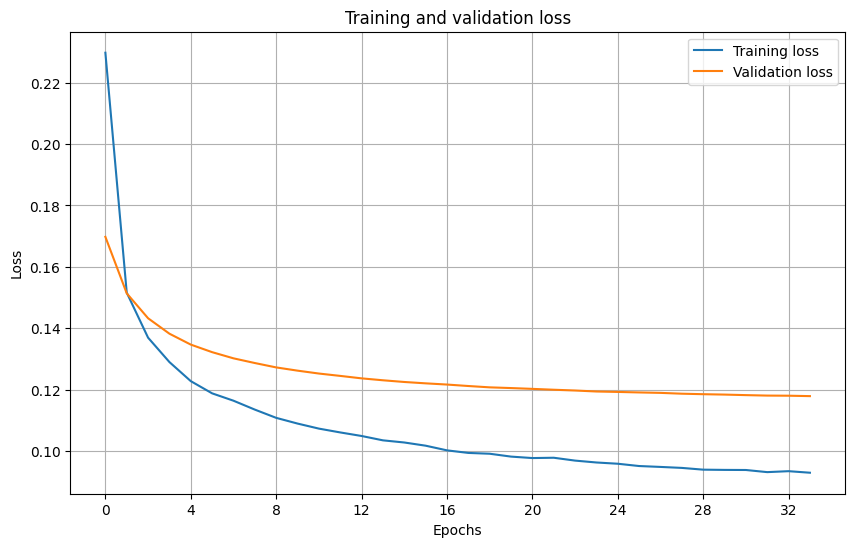

In [20]:
# visualize train and val loss
train_loss = history.history['loss']
val_loss = history.history.get('val_loss')

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

In [21]:
saving.save_model(model, model_path)

## Evaluation

In [22]:
test_accuracy = model.evaluate(test_ds)
print(f'Test accuracy: {test_accuracy[1] * 100:3.2f}%')

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7985 - loss: 0.1009
Test accuracy: 76.17%


In [23]:
test2_accuracy = model.evaluate(test2_ds)
print(f'Test2 accuracy: {test2_accuracy[1] * 100:3.2f}%')

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.7721 - loss: 9.9208
Test2 accuracy: 74.53%


In [24]:
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # append true labels based on their format
    if len(labels.shape) > 1:  # if one-hot encoded
        true_labels.append(np.argmax(labels.numpy(), axis=1))
    else:  # if integer labels
        true_labels.append(labels.numpy())

    # predict labels
    predictions = model.predict(images)
    predicted_labels.append(np.argmax(predictions, axis=1))

# combine all batches into single arrays
true_labels = np.concatenate(true_labels)
predicted_labels = np.concatenate(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━

In [25]:
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
f1 = f1_score(true_labels, predicted_labels, average='macro')
print(f'Precision: {precision * 100:3.2f}%; Recall: {recall * 100:3.2f}%; F1: {f1 * 100:3.2f}%')

Precision: 76.54%; Recall: 76.17%; F1: 76.19%


In [26]:
cr_dict = classification_report(true_labels, predicted_labels, target_names=class_names, output_dict=True)
cr_df = pd.DataFrame(cr_dict).transpose()
cr_df.to_csv(classification_report_path)
print('Classification report:\n', cr_df)

Classification report:
                   precision    recall  f1-score      support
tiger              0.956081  0.943333  0.949664   300.000000
leopard            0.645283  0.570000  0.605310   300.000000
black_bear         0.843003  0.823333  0.833052   300.000000
other_carnivores   0.837134  0.856667  0.846787   300.000000
deer               0.810277  0.683333  0.741410   300.000000
wild_boar          0.739812  0.786667  0.762520   300.000000
buffalo            0.811448  0.803333  0.807370   300.000000
rhino              0.602210  0.726667  0.658610   300.000000
elephant           0.736842  0.700000  0.717949   300.000000
bird               0.671827  0.723333  0.696629   300.000000
accuracy           0.761667  0.761667  0.761667     0.761667
macro avg          0.765392  0.761667  0.761930  3000.000000
weighted avg       0.765392  0.761667  0.761930  3000.000000


In [27]:
cm = confusion_matrix(true_labels, predicted_labels)
print('Confusion matrix:\n', cm)

Confusion matrix:
 [[283   2   2   1   0   3   0   6   0   3]
 [  2 171   5   3   4  11   5  68  10  21]
 [  0   5 247   1  10  11   4  16   3   3]
 [  1   5   0 257   6  12  13   2   1   3]
 [  1  15  19   8 205  22   9   8   7   6]
 [  2  11   2   6  12 236  16   2   6   7]
 [  2   5   4  15   6   6 241  11   2   8]
 [  2  21   9   5   2   4   7 218  16  16]
 [  3  18   3   6   3   8   1   9 210  39]
 [  0  12   2   5   5   6   1  22  30 217]]


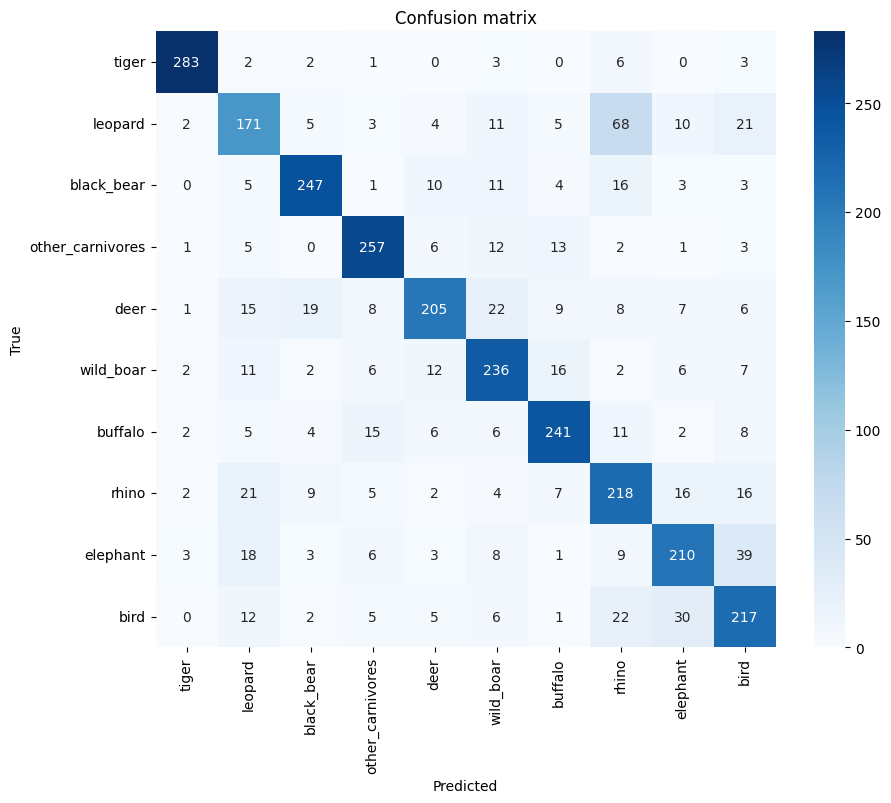

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
plt.show()

## Log run to W&B

In [29]:
if logging:
    run = wandb.init(
        project=wb_project,
        config={
            'model_constructor': model_constructor,
            'model_params': model_params,
            'frozen_file_size': frozen_file_size,
            'num_classes': num_classes,
            'n_train_images': n_train_images,
            'n_test_images': n_test_images,
            'batch_size': batch_size,
            'epochs': epochs,
        },
    )
    wandb.log({
        'training_time_mins': training_time_mins,
        'test_accuracy': round(test_accuracy[1], 4),
        'test2_accuracy': round(test2_accuracy[1], 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
    })
    artifact = wandb.Artifact('classification_results', type='evaluation')
    artifact.add_file(classification_report_path)
    artifact.add_file(confusion_matrix_path)
    wandb.log_artifact(artifact)
    wandb.finish()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: alexvmt. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.18.7
wandb: Run data is saved locally in /wandb/run-20250320_124255-c41bplrv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run iconic-morning-13
wandb: ⭐️ View project at https://wandb.ai/alexvmt/TeraiNet
wandb: 🚀 View run at https://wandb.ai/alexvmt/TeraiNet/runs/c41bplrv
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:                 f1 ▁
wandb:          precision ▁
wandb:             recall ▁
wandb:     test2_accuracy ▁
wandb:      test_accuracy ▁
wandb: training_time_mins ▁
wandb: 
wandb: Run summary:
wandb:                 f1 0.7619
wandb:          precision 0.7654
wandb:             recall 0.7617
wandb:     test2_accuracy 0.7453
wandb:      test_accuracy 0.7